In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Mathematical Analysis of Vector Similarity Measures 
### A Linear Algebra Approach with Recruitment Motivation

# Table of Contents
1. [Introduction](#1.-Introduction)
2. [Vector Space Representation](#2.-Vector-Space-Representation-of-Profiles)
3. [Distance Measures](#3.-Distance-Measures)
4. [Dot Product and Cosine Similarity](#4.-Dot-Product-and-Cosine-Similarity)
5. [Scale Behavior Analysis](#5.-Scale-Behavior-Analysis)
6. [Comparative Analysis](#6.-Comparative-Analysis)
7. [Conclusion](#7.-Conclusion)
8. [References](#8.-References)

## 1. Introduction

In many decision-making systems, it is necessary to measure similarity between profiles.
One practical example is recruitment, where a candidate profile must be compared to a job description.

Instead of using complex AI models, this project focuses on a purely mathematical framework.
We represent profiles as vectors in ℝ^d and analyze different similarity and distance measures.

This abstraction allows us to study the mathematical properties of these measures independently of any specific application.

While similarity metrics are frequently used in machine learning systems, they are often applied without a detailed understanding of their geometric and mathematical behavior. 
Before introducing complex AI models, it is essential to analyze the underlying mathematical structure of similarity measures. 
This project isolates the problem at the level of linear algebra in order to understand how different metrics encode different notions of “closeness” and how those notions influence decision-making.

---

## 2. Vector Space Representation of Profiles

Instead of defining vectors purely abstractly, we motivate their use
in the context of recruitment.

In candidate evaluation, both a candidate profile and a job description
can be represented as collections of measurable characteristics.
To analyze them mathematically, we model each profile as a vector
in a finite-dimensional Euclidean space.

### 2.1 Space Formulation

Each candidate or job description is represented as a point (vector)
in a $d$-dimensional Euclidean space $\mathbb{R}^d$.

We define the vector $x$ as:

$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_d
\end{bmatrix}
\in \mathbb{R}^d
$$

Each dimension $i \in \{1, \dots, d\}$ corresponds to a quantitative feature.
Examples may include years of experience, proficiency level scaled between 0 and 1,
or number of completed projects.

The dimension $d$ denotes the total number of features used in the model.

### 2.2 Modeling Assumptions

For the purposes of this mathematical framework, we introduce the following assumptions:

1. **Numerical Representation**  
   All qualitative characteristics (such as communication skills)
   are assumed to be converted into numerical values using an appropriate scale.

2. **Equal Dimensionality**  
   The candidate vector $c$ and the job description vector $j$
   must have the same dimension $d$.

3. **Feature Independence Assumption**  
   For simplicity, each feature is treated as an independent coordinate dimension.
   Possible correlations between features are not explicitly modeled
   within this linear framework.

### 2.3 Numerical Example

To illustrate the vector representation, consider a simplified case with $d = 3$ features:

1. Years of experience (scaled between 0 and 1)  
2. Technical proficiency (scaled between 0 and 1)  
3. Project experience score (scaled between 0 and 1)

Suppose a candidate is represented by:

$$
c =
\begin{bmatrix}
0.8 \\
0.7 \\
0.9
\end{bmatrix}
$$

and the corresponding job description is represented by:

$$
j =
\begin{bmatrix}
0.9 \\
0.6 \\
0.8
\end{bmatrix}
$$

Both vectors belong to $\mathbb{R}^3$.

We will use this mathematical abstraction to define and compare
different similarity and distance measures in the following sections.

### 2.4 Limitations of the Model

The mathematical abstraction presented in this project intentionally simplifies reality. 
In real-world recruitment systems, features are often correlated, and their relationships may carry additional meaning that is not captured in a purely linear representation. 

Furthermore, the numerical scaling of qualitative characteristics may influence the outcome of distance-based comparisons. 
The choice of similarity metric is therefore not neutral; it reflects implicit assumptions about what constitutes a “good match”.

---

## 3. Distance Measures

### 3.1 Euclidean Distance (L2)

Given two vectors $x, y \in \mathbb{R}^d$, the Euclidean distance is defined as:

$$
\|x - y\|_2 =
\sqrt{\sum_{i=1}^{d} (x_i - y_i)^2}
$$

This represents the geometric distance between two vectors.

### 3.2 Manhattan Distance (L1)

The L1 distance is defined as:

$$
\|x - y\|_1 =
\sum_{i=1}^{d} |x_i - y_i|
$$

This measures the total absolute coordinate difference.

In [11]:
EPS = 1e-12


def l_l2_distance(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    return float(np.sqrt(np.sum((x - y)**2)))


def l_l1_distance(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    return float(np.sum(np.abs(x - y)))


def dot_product(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    return float(np.sum(x * y))


def l2_norm(x):
    x = np.array(x, dtype=float)
    return float(np.sqrt(np.sum(x**2)))


def cosine_similarity(x, y):
    return float(dot_product(x, y) / (l2_norm(x) * l2_norm(y) + EPS))

---

## 4. Dot Product and Cosine Similarity

### 4.1 Dot Product

The dot product is defined as:

$$
x \cdot y =
\sum_{i=1}^{d} x_i y_i
$$

### 4.2 Cosine Similarity

Cosine similarity is defined as:

$$
\cos(x, y) =
\frac{x \cdot y}{\|x\|_2 \|y\|_2}
$$

Properties:

- $\cos(x,y) = 1$ → same direction  
- $\cos(x,y) = 0$ → orthogonal vectors  
- $\cos(x,y) = -1$ → opposite direction

In [3]:
examples = [
    ((1, 0), (0, 1)),    # orthogonal
    ((1, 2), (2, 4)),    # same direction
    ((1, 0), (-1, 0)),   # opposite direction
]

for x, y in examples:
    print("x =", x, " y =", y)
    print("  L1  =", l_l1_distance(x, y))
    print("  L2  =", l_l2_distance(x, y))
    print("  cos =", cosine_similarity(x, y))
    print()

x = (1, 0)  y = (0, 1)
  L1  = 2.0
  L2  = 1.4142135623730951
  cos = 0.0

x = (1, 2)  y = (2, 4)
  L1  = 3.0
  L2  = 2.23606797749979
  cos = 0.9999999999998999

x = (1, 0)  y = (-1, 0)
  L1  = 2.0
  L2  = 2.0
  cos = -0.9999999999989999



### 4.3 Geometric Interpretation in ℝ²

To better understand cosine similarity, we visualize vectors in ℝ².

Cosine similarity measures the angle between vectors.
Vectors with small angles have high cosine similarity,
while vectors with large angles have lower similarity.

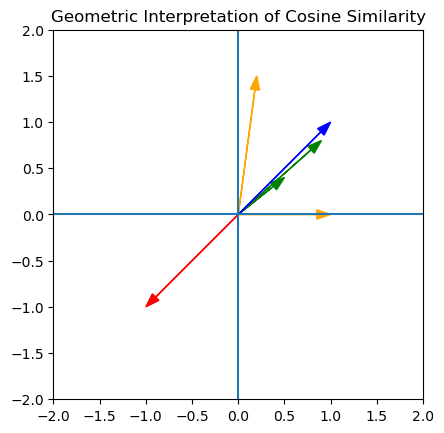

In [5]:
jd = np.array([1, 1])

candidates = [
    np.array([0.9, 0.8]),
    np.array([0.5, 0.4]),
    np.array([-1, -1]),
    np.array([1, 0]),
    np.array([0.2, 1.5])
]

plt.figure()

for c in candidates:
    cos_val = cosine_similarity(c, jd)
    if cos_val > 0.8:
        color = "green"
    elif cos_val < 0.3:
        color = "red"
    else:
        color = "orange"
    plt.arrow(0, 0, c[0], c[1],
              head_width=0.1,
              length_includes_head=True,
              color=color)

plt.arrow(0, 0, jd[0], jd[1],
          head_width=0.1,
          length_includes_head=True,
          color="blue")

plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', 'box')

plt.title("Geometric Interpretation of Cosine Similarity")
plt.show()

### 4.4 Relationship between $L_2$ Distance and Cosine Similarity
To deepen our analysis, we can mathematically demonstrate how Euclidean distance relates to Cosine similarity. For any two normalized vectors $x$ and $y$ (where $\|x\|_2 = \|y\|_2 = 1$), the squared Euclidean distance is:

$$\|x - y\|_2^2 = (x - y) \cdot (x - y) = \|x\|_2^2 + \|y\|_2^2 - 2(x \cdot y)$$

Since the vectors are normalized, this simplifies to:

$$\|x - y\|_2^2 = 1 + 1 - 2\cos(\theta) = 2(1 - \cos(\theta))$$

**Insight:** This proves that for normalized data, minimizing the Euclidean distance is mathematically equivalent to maximizing the Cosine similarity.

---

## 5. Scale Behavior Analysis

### 5.1 Scale Sensitivity of L2

Scaling a vector changes its magnitude.
Therefore, L2 distance changes under scaling.

### 5.2 Scale Invariance of Cosine Similarity

For any $\alpha > 0$:

$$
\cos(\alpha x, y) = \cos(x, y)
$$

Cosine similarity depends only on direction, not magnitude.

In [13]:
x = (1, 2)
y = (2, 4)

for alpha in [0.5, 1, 2, 10]:
    x_scaled = tuple(alpha * np.array(x))
    print("alpha =", alpha, 
          "cos(alpha*x, y) =", cosine_similarity(x_scaled, y))

alpha = 0.5 cos(alpha*x, y) = 0.9999999999997998
alpha = 1 cos(alpha*x, y) = 0.9999999999998999
alpha = 2 cos(alpha*x, y) = 0.9999999999999499
alpha = 10 cos(alpha*x, y) = 0.9999999999999899


### 5.3 Weighted Vector Representation
In a real-world recruitment scenario, not all features carry the same importance. We can introduce a weight vector $w \in \mathbb{R}^d$ to emphasize critical skills. The weighted dot product is defined as:

$$x \cdot_w y = \sum_{i=1}^{d} w_i x_i y_i$$

In [8]:
# Пример за тегловна прилика
weights = np.array([0.2, 1.5, 1.0]) # Техническите умения са 7.5 пъти по-важни от стажа


def weighted_cosine(x, y, w):
    # Математически прилагаме теглата преди изчисляване
    x_w = np.array(x) * np.sqrt(w)
    y_w = np.array(y) * np.sqrt(w)
    return cosine_similarity(x_w, y_w)

# Сравнение на резултатите
c1 = [0.9, 0.4, 0.8] # Силни основи, слаба техника
jd = [0.8, 0.8, 0.8]
print(f"Standard Cosine: {cosine_similarity(c1, jd):.4f}")
print(f"Weighted Cosine: {weighted_cosine(c1, jd, weights):.4f}")

Standard Cosine: 0.9555
Weighted Cosine: 0.9420


---

## 6. Comparative Analysis

In this section, we evaluate how different mathematical metrics - L1 (Manhattan), L2 (Euclidean), and Cosine Similarity - interpret the relationship between candidate profiles and job descriptions. While all three measure "closeness" in $\mathbb{R}^d$, they capture fundamentally different notions of similarity.

- L1 and L2 Distances: These metrics focus on geometric separation. They are highly sensitive to the magnitude of the vectors, meaning they prioritize the absolute level of experience.
- Cosine Similarity: This metric focuses on angular alignment. It is scale-invariant, meaning it prioritizes the "mix" or proportion of skills rather than the total years of experience.

### 6.1 Practical Experiment: Junior vs. Senior Profiles
To demonstrate these differences, we simulate a scenario where a Job Description (JD) requires an equal balance of two specific skills. We then compare a "Junior" candidate with a perfect skill mix but low values, and a "Specialized" candidate with high values in only one area.

In [14]:
# Job Description (JD): Seeking a balanced 1:1 ratio of Skill A and Skill B
jd = np.array([1.0, 1.0])

# Candidate 1: Perfect skill balance but low experience (Junior)
c1 = np.array([0.2, 0.2])

# Candidate 2: Very high experience but unbalanced (Specialist)
c2 = np.array([0.9, 0.1])


def compare_metrics(candidate, target, name):
    # L2 Distance (Euclidean)
    l2_dist = np.sqrt(np.sum((candidate - target)**2))

    # Cosine Similarity
    norm_c = np.sqrt(np.sum(candidate**2))
    norm_t = np.sqrt(np.sum(target**2))
    cos_sim = np.dot(candidate, target) / (norm_c * norm_t + 1e-12)

    print(f"--- Results for {name} ---")
    print(f"L2 Distance: {l2_dist:.4f} (Lower is closer)")
    print(f"Cosine Similarity: {cos_sim:.4f} (Higher is better)\n")

compare_metrics(c1, jd, "Candidate 1 (Junior - Balanced)")
compare_metrics(c2, jd, "Candidate 2 (Specialist - Unbalanced)")

--- Results for Candidate 1 (Junior - Balanced) ---
L2 Distance: 1.1314 (Lower is closer)
Cosine Similarity: 1.0000 (Higher is better)

--- Results for Candidate 2 (Specialist - Unbalanced) ---
L2 Distance: 0.9055 (Lower is closer)
Cosine Similarity: 0.7809 (Higher is better)



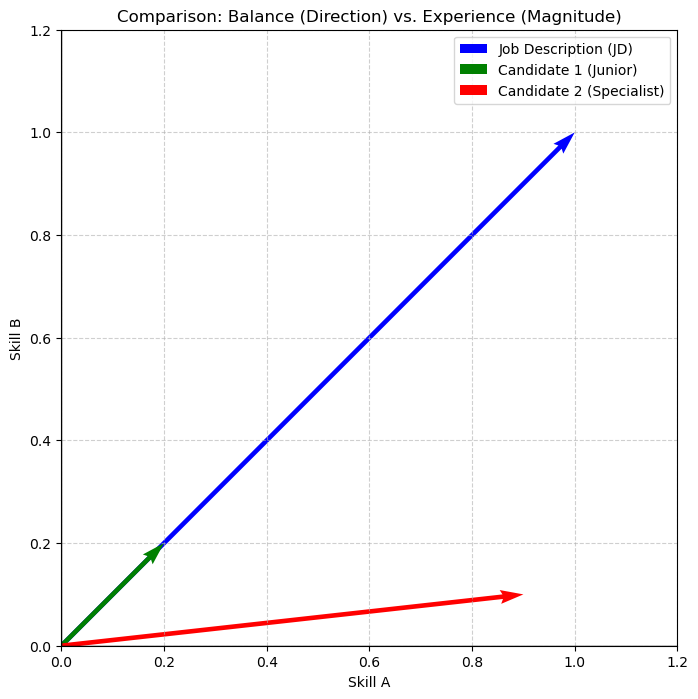

In [12]:
def plot_comparison(jd, c1, c2):
    plt.figure(figsize=(8, 8))

    vectors = [jd, c1, c2]
    colors = ['blue', 'green', 'red']
    labels = ['Job Description (JD)', 'Candidate 1 (Junior)', 'Candidate 2 (Specialist)']
    
    for v, color, label in zip(vectors, colors, labels):
        plt.quiver(0, 0, v[0], v[1], color=color, angles='xy', scale_units='xy', scale=1, label=label)

    plt.xlim(0, 1.2)
    plt.ylim(0, 1.2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.legend()
    plt.title("Comparison: Balance (Direction) vs. Experience (Magnitude)")
    plt.xlabel("Skill A")
    plt.ylabel("Skill B")
    plt.gca().set_aspect('equal')
    plt.show()

plot_comparison(jd, c1, c2)

### 6.2 Analysis of Results

- The Magnitude Paradox: According to the L2 Distance, the Specialist (Candidate 2) might appear "closer" to the ideal profile because their total values are higher.
- The Directional Advantage: Cosine Similarity identifies Candidate 1 as a perfect match (1.000) because their skill proportions exactly match the JD, even though they lack the absolute magnitude of experience.
- Conclusion for Recruitment: A robust mathematical framework should ideally use a combination of these metrics. Cosine similarity identifies the right type of candidate, while L2 distance confirms if they have the required seniority.

## 7. Conclusion
This project presented a comprehensive mathematical study of similarity and distance measures within a $d$-dimensional Euclidean space $\mathbb{R}^d$. By abstracting recruitment profiles into vectors, we established a theoretical foundation for objective decision-making in candidate evaluation.

**Key Takeaways:**
- Vector Representation: Modeling qualitative characteristics as numerical vectors allows for rigorous analytical comparison using linear algebra.
- Metric Differentiation: While Euclidean distance captures absolute geometric separation (useful for measuring total years of experience), Cosine similarity is more effective at identifying the specific balance of skills, as it remains invariant to the scale of the vector.
- Mathematical Stability: To ensure the robustness of the implementation and prevent undefined operations (division by zero), a constant EPS was integrated into the similarity formulas.
- Problem Formulation: The transition from real-world recruitment challenges to a mathematical counterpart was executed by defining specific modeling assumptions, such as feature independence and equal dimensionality.

**Future Work:**
- Future iterations of this project could explore more advanced techniques to enhance the model's accuracy:
- Weighted Similarity: Implementing weight matrices to prioritize core technical skills over secondary traits.
Jaccard Similarity: Applying set-based metrics for binary skill sets where only the presence or absence of a skill is recorded.
- Dimensionality Analysis: Investigating how the "curse of dimensionality" affects distance measures as the number of job requirements grows.
- Such vector-based similarity approaches are also widely used in machine learning systems (e.g., recommendation systems, embeddings, clustering), where entities are compared in high-dimensional feature spaces.

---

## 8. References

During the development of this project, the following resources and libraries were utilized:

* **NumPy Documentation**: Used for implementing vector operations, dot products, and norm calculations.
* **Matplotlib Pyplot**: Used for the geometric visualization of vectors and similarity analysis. 
* **Python Documentation**: Best practices for function definitions and numerical stability (EPS). 
* **Course Materials**: Mathematical foundations of Linear Algebra and Vector Spaces as per the exam project guidelines. 
* **Markdown and LaTeX**: Used for professional scientific documentation and formula rendering.